# 01 · Laboratorio 2D — la matriz 3 × 4 con score exacto y aprendido

Notebook único del estudio de ablación sobre la **mezcla de 8 gaussianas**. Reemplaza y absorbe los seis notebooks 2D previos
(dato y forward, entrenamiento y sampleo, reconstrucción desde checkpoint, y los tres de auditoría: marginales, score vs
epsilon, ruido del último paso).

La matriz del estudio son **dos ejes independientes**:

- **Eje 1 — forward SDE** (`vp`, `ve`, `sub_vp`): define cómo se destruye la distribución hacia ruido, y por lo tanto el score
  que hay que aprender. Cambiarlo **obliga a reentrenar**.
- **Eje 2 — sampler del reverso** (`euler`, `pf_ode`, `heun`, `pc`): integra el mismo score de distintas formas. Cambiarlo
  **no** requiere reentrenar.

Eso da **3 × 4 = 12 celdas**, y acá se corren **dos veces**:

| grilla | score | qué aísla |
|---|---|---|
| **A** | **exacto**, del oráculo analítico | toda diferencia entre celdas es del **sampler** (Eje 2 puro) |
| **B** | **aprendido**, red entrenada por DSM | lo que pasa de verdad, con el error de la red incluido |

Comparar A contra B es lo que **separa el error de estimación del score del error de discretización**. Sin el score exacto los
dos vienen mezclados y son indistinguibles: es el desbloqueo concreto que da tener la densidad en forma cerrada.

### El desbloqueo analítico

Si $p_0 = \sum_k w_k\,\mathcal N(\mu_k, \Sigma_k)$ y el kernel forward es gaussiano, entonces $p_t$ **sigue siendo** una mezcla
de gaussianas:

$$p_t = \sum_k w_k\,\mathcal N\!\left(\alpha_t \mu_k,\; \alpha_t^2\Sigma_k + \sigma_t^2 I\right)$$

y por lo tanto hay **score exacto en todo $(x,t)$**:

$$\nabla\log p_t(x) = -\sum_k r_k(x,t)\,\Sigma_k(t)^{-1}\!\left(x - \alpha_t\mu_k\right),\qquad r_k = \text{responsabilidad posterior}$$

> **Device**: el notebook detecta CUDA y enruta a GPU lo que puede aprovecharla —el entrenamiento, el sampleo de las 24 celdas y
> las evaluaciones de score—. La **cuadratura 2D corre siempre en CPU** por diseño (es una utilidad numérica autónoma, sin
> parámetro de device), así que las celdas de masa y de sesgo de inicialización no cambian con la GPU; tampoco hace falta, son
> segundos.
>
> **Costo de correr esto**: en CPU, entrenar las tres SDEs son ~11 min (9600 pasos cada una, medido) y la grilla con red
> entrenada ~2 min; en GPU ambas caen mucho. El resto es de segundos. Si no hay GPU visible el notebook avisa y corre igual.

In [18]:
# --- Setup: bootstrap de sys.path + imports + helpers ---
import sys
import pathlib
import time

_here = pathlib.Path.cwd()
_root = None
for _cand in (_here, *_here.parents):
    if (_cand / "src" / "diffusion").is_dir():
        _root = _cand
        break
if _root is None:
    raise RuntimeError(f"No encontré src/diffusion subiendo desde {_here}")
_src = str((_root / "src").resolve())
if _src not in sys.path:
    sys.path.insert(0, _src)

import numpy as np
import torch
import matplotlib.pyplot as plt

from diffusion.analytic import MixtureOracle
from diffusion.data_generation import ExactGaussianMixture, infinite_bare
from diffusion.models import ScoreMLP
from diffusion.samplers import available_samplers, make_sampler
from diffusion.sde import make_sde
from diffusion.training import TrainConfig, train

SEED = 1
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# --- Device ---------------------------------------------------------------------
# Se detecta una sola vez y se usa en TODO lo que puede aprovecharlo: el
# entrenamiento (TrainConfig.device), el sampleo (sample(device=...) con un
# generator del mismo device) y los tensores que alimentan a la red y al oraculo.
# El score del oraculo es agnostico al device: promueve sus parametros en cada
# llamada al device del estado que recibe.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# En GPU conviene autotunear las convoluciones/matmuls una vez y habilitar TF32:
# las shapes de este laboratorio son fijas en todos los pasos.
if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")


def a_device(x):
    """numpy o tensor -> tensor float32 en DEVICE."""
    t = torch.as_tensor(x) if not torch.is_tensor(x) else x
    return t.to(device=DEVICE, dtype=torch.float32)


def gen_device(semilla=SEED):
    """Generator en DEVICE: randn con generator exige que coincidan."""
    g = torch.Generator(device=DEVICE)
    g.manual_seed(semilla)
    return g

SDES = ["vp", "ve", "sub_vp"]
SAMPLERS = ["euler", "pf_ode", "heun", "pc"]
T_EPS = 1e-4

# Varianza del prior de cada SDE: es un dato que hay que declarar, porque no se puede
# leer de la SDE de forma exacta y genérica. VP y sub-VP parten de N(0, I); VE de
# N(0, sigma_max^2 I), y sigma_max vale 5 por defecto.
PRIOR_VAR = {"vp": 1.0, "sub_vp": 1.0, "ve": 25.0}

print("paquete en:", _root)
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available(), "| DEVICE:", DEVICE)
print("samplers:", available_samplers())
if DEVICE == "cpu":
    print("AVISO: sin GPU visible. El notebook corre igual, pero el entrenamiento de las")
    print("tres SDEs son ~11 min en CPU (medido) en vez de los segundos que tarda en GPU.")

paquete en: /home/abravo/estocastico/diffusion-models
torch: 2.12.0+cu130 | cuda: True | DEVICE: cuda
samplers: ['euler', 'heun', 'pc', 'pf_ode']


## 1. El dato: una mezcla de 8 gaussianas de parámetros exactos

Acá está el primer cambio respecto de los notebooks viejos. Ellos usaban la mezcla *legacy*, que es isotrópica, de pesos
parejos y **no publica sus centros**; y encima la estandarizaban con una transformación estimada de la propia muestra, así que
los parámetros efectivos dependían de `n` y de la semilla.

El oráculo necesita $(w_k, \mu_k, \Sigma_k)$ **en forma cerrada**, así que usamos la mezcla exacta: los parámetros son entrada
explícita y quedan consultables. Sin eso no hay score exacto, y por lo tanto no hay grilla A.

pesos     : [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
medias[:3]: [[5.    0.   ]
 [3.536 3.536]
 [0.    5.   ]] ...
covarianza de la componente 0:
 [[0.09 0.  ]
 [0.   0.09]]


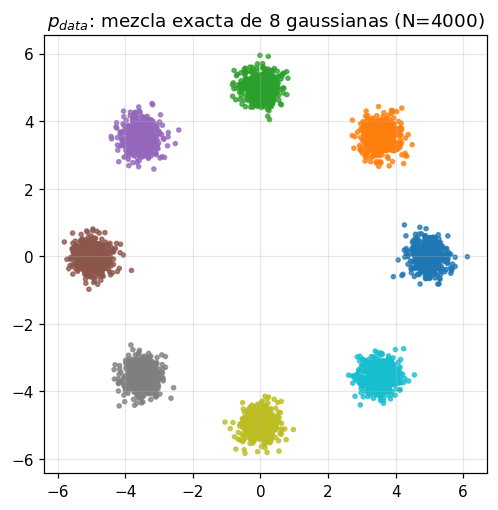

In [19]:
mixtura = ExactGaussianMixture.ring(n_components=8, radius=5.0, scale=0.3, seed=SEED)

N_REF = 4000
x_ref = mixtura.sample(N_REF)          # (N, 2) float32
color_ref = mixtura.color_             # componente de cada punto

print("pesos     :", np.round(mixtura.weights_, 4))
print("medias[:3]:", np.round(mixtura.means_[:3], 3), "...")
print("covarianza de la componente 0:\n", np.round(mixtura.covariances_[0], 4))

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.scatter(x_ref[:, 0], x_ref[:, 1], c=color_ref, cmap="tab10", s=7, alpha=0.75)
ax.set_aspect("equal")
ax.set_title(f"$p_{{data}}$: mezcla exacta de 8 gaussianas (N={N_REF})")
plt.show()

## 2. El forward: cómo cada SDE destruye el dato

Snapshots de $x_t$ a tiempos crecientes, más el prior del que arranca el reverso. Los límites de los ejes se comparten
**por columna**: a un mismo tiempo las tres SDEs se dibujan en la misma escala, así la comparación es justa, y como las
columnas difieren entre sí el **estado final** de cada SDE queda directamente comparable.

- **VP** y **sub-VP** contraen la media hacia cero y acotan la varianza → prior $\mathcal N(0,I)$.
- **VE** mantiene la media y **explota la varianza** → prior $\mathcal N(0,\sigma_{max}^2 I)$, mucho más ancho.

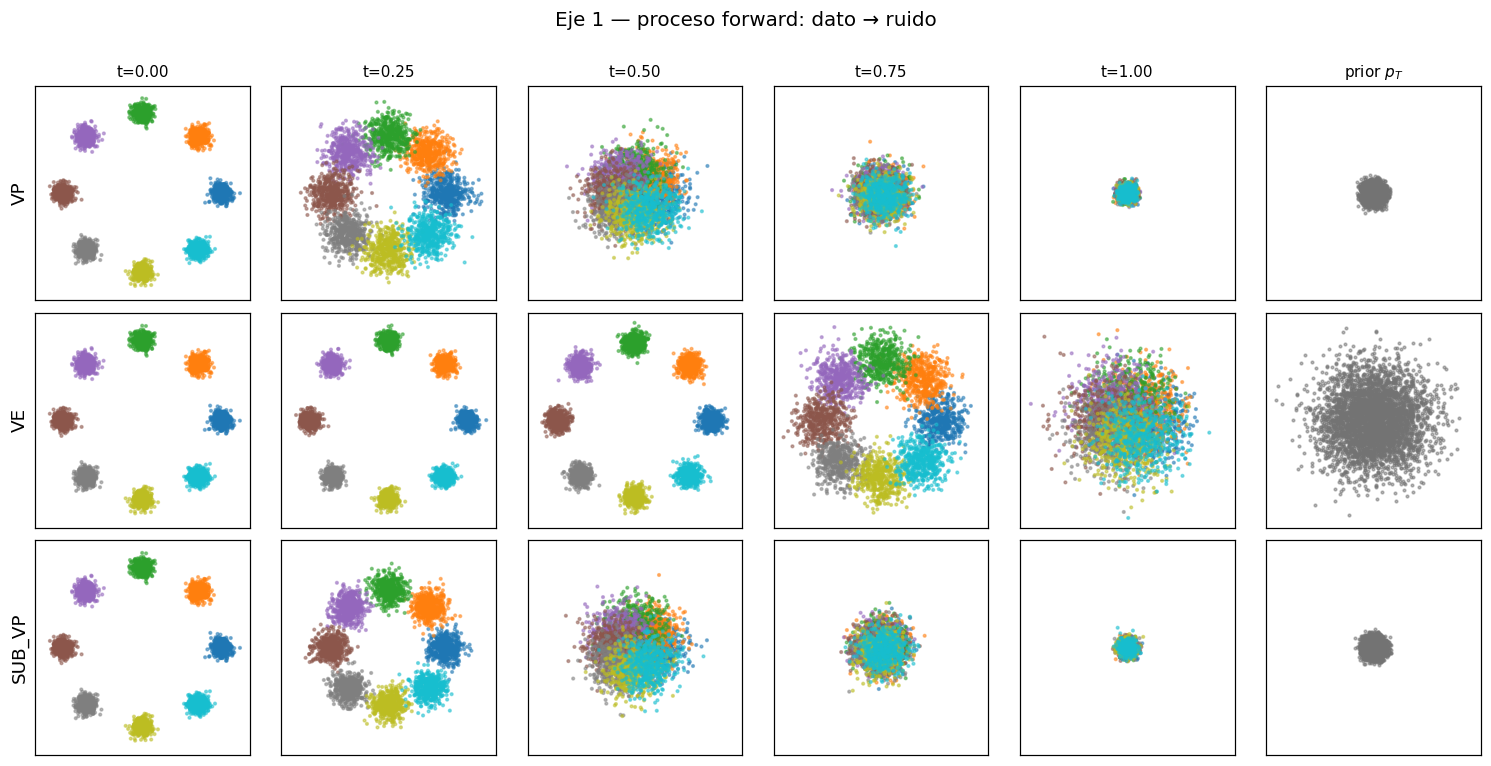

In [20]:
times = [T_EPS, 0.25, 0.5, 0.75, 1.0]
col_titles = [f"t={t:.2f}" for t in times] + ["prior $p_T$"]
x0_t = a_device(x_ref)
gen = gen_device()

nubes = []
for nombre in SDES:
    sde = make_sde(nombre)
    fila = []
    for t in times:
        tt = torch.full((x0_t.shape[0],), float(t), device=DEVICE)
        xt, _ = sde.perturb(x0_t, tt, generator=gen)
        fila.append(xt.cpu().numpy())
    fila.append(sde.prior_sampling((x0_t.shape[0], *sde.data_shape),
                                   generator=gen, device=DEVICE).cpu().numpy())
    nubes.append(fila)

# Escala compartida por columna (mismo t => misma escala entre SDEs).
lims = [1.1 * max(float(np.abs(nubes[i][j]).max()) for i in range(len(SDES)))
        for j in range(len(times) + 1)]

fig, axes = plt.subplots(len(SDES), len(times) + 1,
                         figsize=(2.3 * (len(times) + 1), 2.3 * len(SDES)))
for i, nombre in enumerate(SDES):
    for j in range(len(times) + 1):
        ax = axes[i, j]
        nube = nubes[i][j]
        if j < len(times):
            ax.scatter(nube[:, 0], nube[:, 1], c=color_ref, cmap="tab10", s=3, alpha=0.5)
        else:
            ax.scatter(nube[:, 0], nube[:, 1], c="0.45", s=3, alpha=0.5)
        ax.set_xlim(-lims[j], lims[j]); ax.set_ylim(-lims[j], lims[j])
        ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.set_title(col_titles[j], fontsize=10)
    axes[i, 0].set_ylabel(nombre.upper(), fontsize=12)
fig.suptitle("Eje 1 — proceso forward: dato → ruido", y=1.002, fontsize=13)
fig.tight_layout()
plt.show()

## 3. El oráculo: densidad y score exactos

Con la mezcla exacta y una SDE, el oráculo da $p_t$, $\log p_t$ y $\nabla\log p_t$ cerrados. Abajo: la densidad exacta como
contorno y el score exacto como quiver, en dos tiempos. A $t$ chico el campo apunta a los 8 modos; a $t$ grande se aplana
hacia el origen.

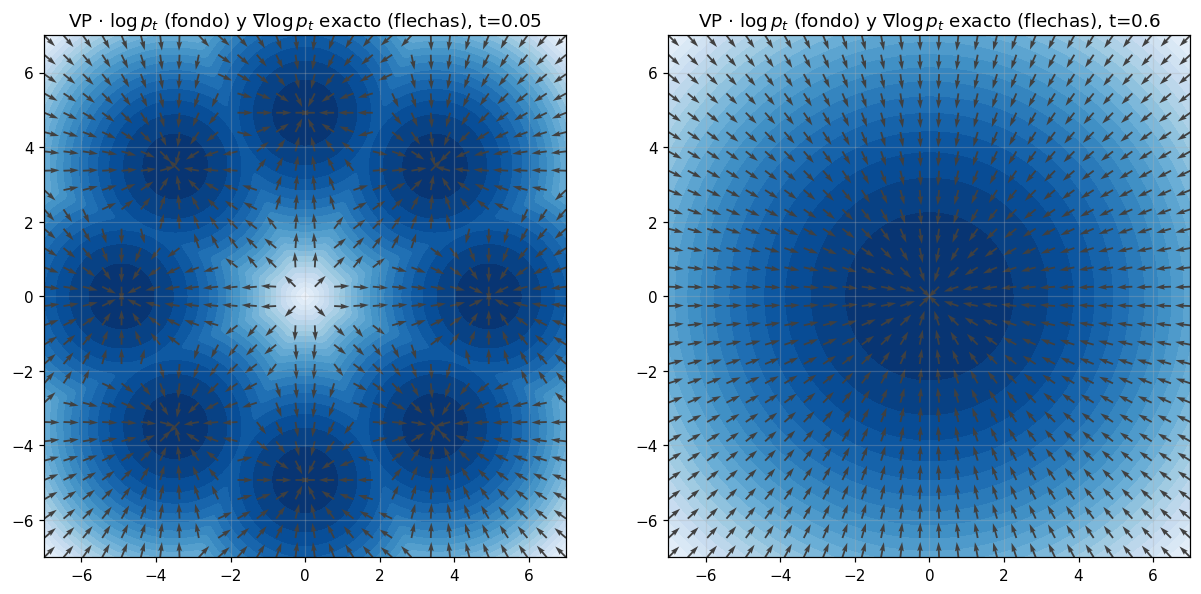

In [21]:
def campo_y_densidad(oraculo, t_val, lim, n=28, n_dens=160):
    """Score (quiver, normalizado) y log-densidad (contorno) exactos en una grilla."""
    xs = np.linspace(-lim, lim, n)
    gx, gy = np.meshgrid(xs, xs)
    pts = a_device(np.stack([gx.ravel(), gy.ravel()], 1))
    tt = torch.full((pts.shape[0],), float(t_val), device=DEVICE)
    s = oraculo.score(pts, tt).cpu().numpy()

    ds = np.linspace(-lim, lim, n_dens)
    dx, dy = np.meshgrid(ds, ds)
    dpts = a_device(np.stack([dx.ravel(), dy.ravel()], 1))
    dtt = torch.full((dpts.shape[0],), float(t_val), device=DEVICE)
    logp = oraculo.log_prob(dpts, dtt).cpu().numpy().reshape(n_dens, n_dens)
    return gx, gy, s, dx, dy, logp


oraculo_vp = MixtureOracle(mixtura, make_sde("vp"))
t_vals = [0.05, 0.6]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.4))
for ax, tv in zip(axes, t_vals):
    gx, gy, s, dx, dy, logp = campo_y_densidad(oraculo_vp, tv, lim=7.0)
    ax.contourf(dx, dy, logp, levels=25, cmap="Blues")
    mag = np.linalg.norm(s, axis=1)
    ax.quiver(gx.ravel(), gy.ravel(), s[:, 0] / (mag + 1e-9), s[:, 1] / (mag + 1e-9),
              color="0.25", scale=34, width=0.0035)
    ax.set_aspect("equal")
    ax.set_title(f"VP · $\\log p_t$ (fondo) y $\\nabla\\log p_t$ exacto (flechas), t={tv}")
fig.tight_layout()
plt.show()

### Sesgo de inicialización, por SDE

El sampler arranca del prior de su SDE, pero la distribución real en $t=T$ **no es** exactamente ese prior. Esa diferencia es
un sesgo que se paga antes de dar el primer paso.

Se reportan **dos números** porque la divergencia entre una mezcla y una gaussiana **no tiene forma cerrada** (la entropía
diferencial de una mezcla no la tiene; solo el término cruzado). Así que: una **cota superior** rigurosa de forma cerrada, por
convexidad de la KL, y un **valor de referencia** por cuadratura 2D con su tolerancia. La cota domina al valor, y con una sola
componente coinciden.

In [22]:
print(f"{'SDE':8s} {'cota':>12s} {'valor':>12s} {'tolerancia':>12s} {'masa':>10s}")
for nombre in SDES:
    ora = MixtureOracle(mixtura, make_sde(nombre))
    rep = ora.initialization_bias(PRIOR_VAR[nombre])
    print(f"{nombre:8s} {rep.bound:12.6f} {rep.value:12.6f} {rep.tolerance:12.2e} {rep.mass:10.6f}")

print("\nVP y sub-VP contraen la media, así que llegan cerca de su prior N(0,I).")
print("VE solo agranda la varianza: su sesgo es órdenes de magnitud mayor, y solo baja")
print("si sigma_max domina la escala del dato.")

SDE              cota        valor   tolerancia       masa
vp           0.000540     0.000000     1.06e-04   1.000000
ve           0.500006     0.097706     8.57e-05   1.000000
sub_vp       0.000540     0.000000     1.06e-04   1.000000

VP y sub-VP contraen la media, así que llegan cerca de su prior N(0,I).
VE solo agranda la varianza: su sesgo es órdenes de magnitud mayor, y solo baja
si sigma_max domina la escala del dato.


## 4. Entrenar las tres SDEs

Cambiar el forward SDE **obliga a reentrenar** (cada SDE define una $p_t$ distinta y por lo tanto otro score). La red es la
**variable de control**: misma arquitectura y mismos hiperparámetros en las tres celdas, así toda diferencia se atribuye a la
matemática y no a la ingeniería.

⏱️ **~11 min en CPU** (9600 pasos por SDE).

[vp] paso 5000/50000  pérdida(móvil)=0.378826
[vp] paso 10000/50000  pérdida(móvil)=0.329010
[vp] paso 15000/50000  pérdida(móvil)=0.326099
[vp] paso 20000/50000  pérdida(móvil)=0.321498
[vp] paso 25000/50000  pérdida(móvil)=0.321652
[vp] paso 30000/50000  pérdida(móvil)=0.319418
[vp] paso 35000/50000  pérdida(móvil)=0.317717
[vp] paso 40000/50000  pérdida(móvil)=0.317626
[vp] paso 45000/50000  pérdida(móvil)=0.317038
[vp] paso 50000/50000  pérdida(móvil)=0.316583
  vp        71.3s  loss 0.9548 -> 0.2597
[ve] paso 5000/50000  pérdida(móvil)=0.909037
[ve] paso 10000/50000  pérdida(móvil)=0.748101
[ve] paso 15000/50000  pérdida(móvil)=0.709691
[ve] paso 20000/50000  pérdida(móvil)=0.703481
[ve] paso 25000/50000  pérdida(móvil)=0.703578
[ve] paso 30000/50000  pérdida(móvil)=0.699140
[ve] paso 35000/50000  pérdida(móvil)=0.699881
[ve] paso 40000/50000  pérdida(móvil)=0.698917
[ve] paso 45000/50000  pérdida(móvil)=0.697972
[ve] paso 50000/50000  pérdida(móvil)=0.697691
  ve        63.9s  lo

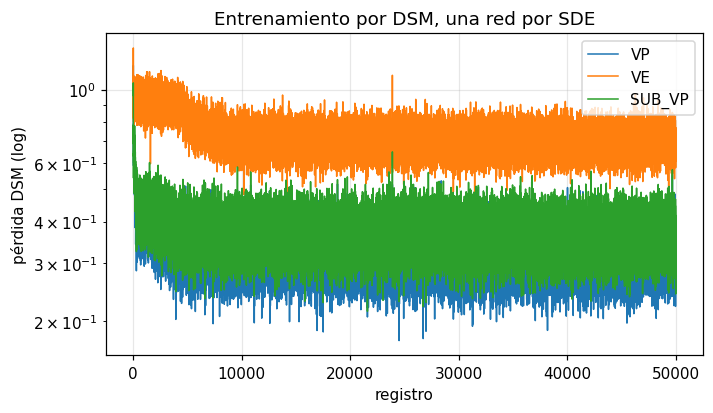

In [23]:
redes = {}
historias = {}
t_inicio = time.time()
for nombre in SDES:
    sde = make_sde(nombre)
    red = ScoreMLP(data_dim=2)                       # misma arquitectura en las tres
    datos = infinite_bare(mixtura.dataloader(5000, 256, shuffle=True))
    cfg = TrainConfig(num_steps=50000, lr=1e-3, t_eps=T_EPS, seed=0,
                      log_every=5000, device=DEVICE)
    t0 = time.time()
    res = train(sde, red, datos, cfg)
    res.net.eval()
    redes[nombre] = res.net
    historias[nombre] = res.history
    print(f"  {nombre:7s} {time.time()-t0:6.1f}s  loss {res.history[0]:.4f} -> {res.history[-1]:.4f}")
print(f"total: {(time.time()-t_inicio)/60:.1f} min")

fig, ax = plt.subplots(figsize=(7, 3.8))
for nombre in SDES:
    ax.plot(historias[nombre], lw=1.0, label=nombre.upper())
ax.set_yscale("log"); ax.set_xlabel("registro"); ax.set_ylabel("pérdida DSM (log)")
ax.set_title("Entrenamiento por DSM, una red por SDE"); ax.legend()
plt.show()

## 5. ¿Dónde vive el error del score?

Ahora que hay score exacto, el error de la red se puede **medir** en vez de suponer: $\mathbb E_{p_t}\|s_\theta - \nabla\log p_t\|^2$
en función de $t$.

Se muestran **dos** curvas porque el absoluto miente: el score verdadero explota como $1/\sigma_t^2$ cuando $t\to 0$, así que un
error absoluto grande ahí puede ser un error **relativo** chiquito. La lectura honesta es la relativa.

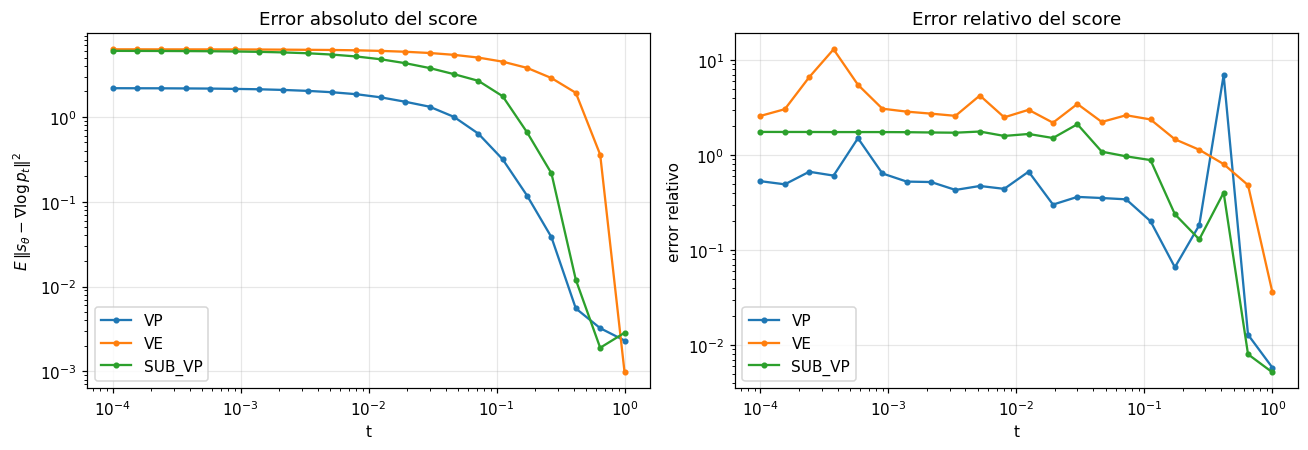

In [24]:
ts = np.geomspace(T_EPS, 1.0, 22)
N_ERR = 3000
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for nombre in SDES:
    sde = make_sde(nombre)
    ora = MixtureOracle(mixtura, sde)
    red = redes[nombre]
    abs_err, rel_err = [], []
    g = gen_device()
    x0 = a_device(mixtura.sample(N_ERR))
    for t in ts:
        tt = torch.full((N_ERR,), float(t), device=DEVICE)
        xt, _ = sde.perturb(x0, tt, generator=g)          # muestras de p_t
        with torch.no_grad():
            s_red = red(xt, tt)
        s_exacto = ora.score(xt, tt)
        num = (s_red - s_exacto).pow(2).sum(1)
        den = s_exacto.pow(2).sum(1)
        abs_err.append(float(num.mean()))
        rel_err.append(float((num / den.clamp_min(1e-30)).mean()))
    axes[0].plot(ts, abs_err, marker="o", ms=3, label=nombre.upper())
    axes[1].plot(ts, rel_err, marker="o", ms=3, label=nombre.upper())

for ax, ttl, yl in zip(axes,
                       ["Error absoluto del score", "Error relativo del score"],
                       [r"$E\,\|s_\theta-\nabla\log p_t\|^2$", "error relativo"]):
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("t"); ax.set_ylabel(yl); ax.set_title(ttl); ax.legend()
fig.tight_layout()
plt.show()

## 6. La grilla 3 × 4

Las 12 celdas, **con el mismo ruido inicial** en cada una (misma semilla), primero con score exacto y después con la red.

Además de mirarlas, se mide una **discrepancia elemental** por celda: se asigna cada muestra a su componente más cercana con la
métrica de Mahalanobis de la $\Sigma_k$ verdadera, y se toma el peor de tres errores adimensionales —pesos, medias en unidades
del radio RMS de la componente, y covarianzas en norma de Frobenius relativa—. Es deliberadamente elemental: $W_2$ exacta y KSD
son de la etapa de métricas, no de acá.

Grilla A: score EXACTO (toda diferencia entre celdas es del sampler)


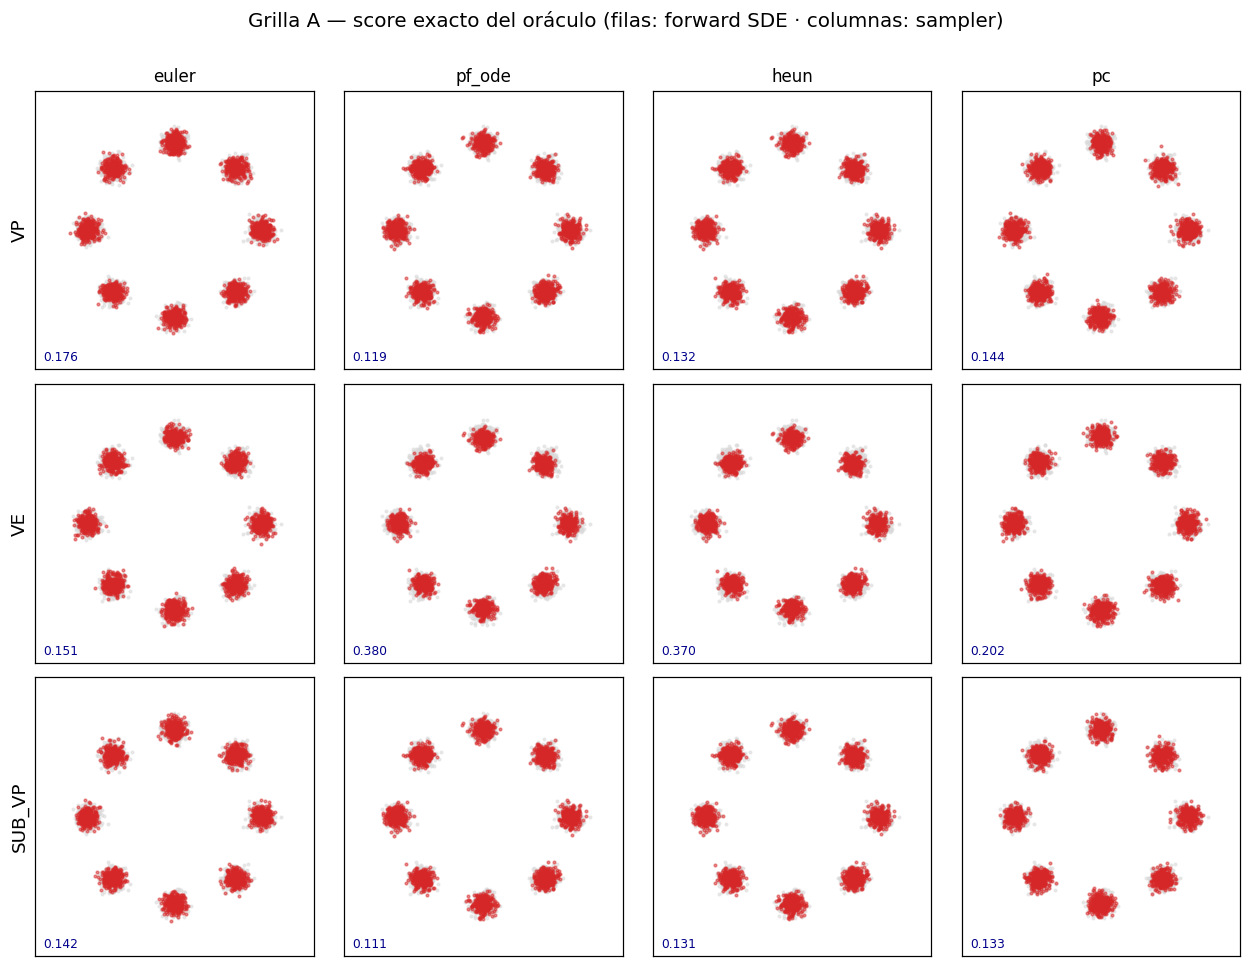

In [25]:
def discrepancia(muestras, mix):
    """Peor de tres errores adimensionales contra los parámetros declarados de la mezcla."""
    x = muestras.astype(np.float64)
    w, mu, cov = mix.weights_, mix.means_, mix.covariances_
    inv = np.linalg.inv(cov)
    d = x[:, None, :] - mu[None]                                  # (N,K,2)
    m2 = np.einsum("nki,kij,nkj->nk", d, inv, d)                  # Mahalanobis^2
    asign = m2.argmin(1)
    peor_w = peor_mu = peor_cov = 0.0
    for k in range(len(w)):
        sel = x[asign == k]
        peor_w = max(peor_w, abs(len(sel) / len(x) - w[k]))
        if len(sel) < 5:
            peor_mu, peor_cov = max(peor_mu, 1.0), max(peor_cov, 1.0)
            continue
        radio = np.sqrt(np.trace(cov[k]))                         # radio RMS
        peor_mu = max(peor_mu, np.linalg.norm(sel.mean(0) - mu[k]) / radio)
        c = np.cov(sel.T)
        peor_cov = max(peor_cov, np.linalg.norm(c - cov[k]) / np.linalg.norm(cov[k]))
    return max(peor_w, peor_mu, peor_cov)


def corre_grilla(score_de, titulo, n=2500, n_steps=200):
    """Samplea las 12 celdas con el mismo x_T y devuelve {(sde,sampler): (muestras, disc)}."""
    out = {}
    fig, axes = plt.subplots(len(SDES), len(SAMPLERS),
                             figsize=(2.9 * len(SAMPLERS), 2.9 * len(SDES)))
    for i, nom_sde in enumerate(SDES):
        sde = make_sde(nom_sde)
        score = score_de(nom_sde, sde)
        for j, nom_s in enumerate(SAMPLERS):
            smp = make_sampler(nom_s, sde, score, n_steps=n_steps, t_eps=T_EPS)
            g = gen_device()                                  # mismo x_T en toda la grilla
            xs = smp.sample(n, generator=g, device=DEVICE).cpu().numpy()
            disc = discrepancia(xs, mixtura)
            out[(nom_sde, nom_s)] = (xs, disc)
            ax = axes[i, j]
            ax.scatter(x_ref[:, 0], x_ref[:, 1], c="0.85", s=3, alpha=0.5, zorder=0)
            ax.scatter(xs[:, 0], xs[:, 1], c="C3", s=3, alpha=0.5, zorder=1)
            ax.set_xlim(-8, 8); ax.set_ylim(-8, 8); ax.set_aspect("equal")
            ax.set_xticks([]); ax.set_yticks([])
            if i == 0:
                ax.set_title(nom_s, fontsize=11)
            ax.text(0.03, 0.03, f"{disc:.3f}", transform=ax.transAxes, fontsize=8,
                    color="darkblue")
        axes[i, 0].set_ylabel(nom_sde.upper(), fontsize=12)
    fig.suptitle(titulo, y=1.005, fontsize=13)
    fig.tight_layout()
    plt.show()
    return out


print("Grilla A: score EXACTO (toda diferencia entre celdas es del sampler)")
t0 = time.time()
grilla_exacta = corre_grilla(
    lambda nombre, sde: MixtureOracle(mixtura, sde),
    "Grilla A — score exacto del oráculo (filas: forward SDE · columnas: sampler)",
)

Grilla B: score APRENDIDO (el error de la red entra en juego)


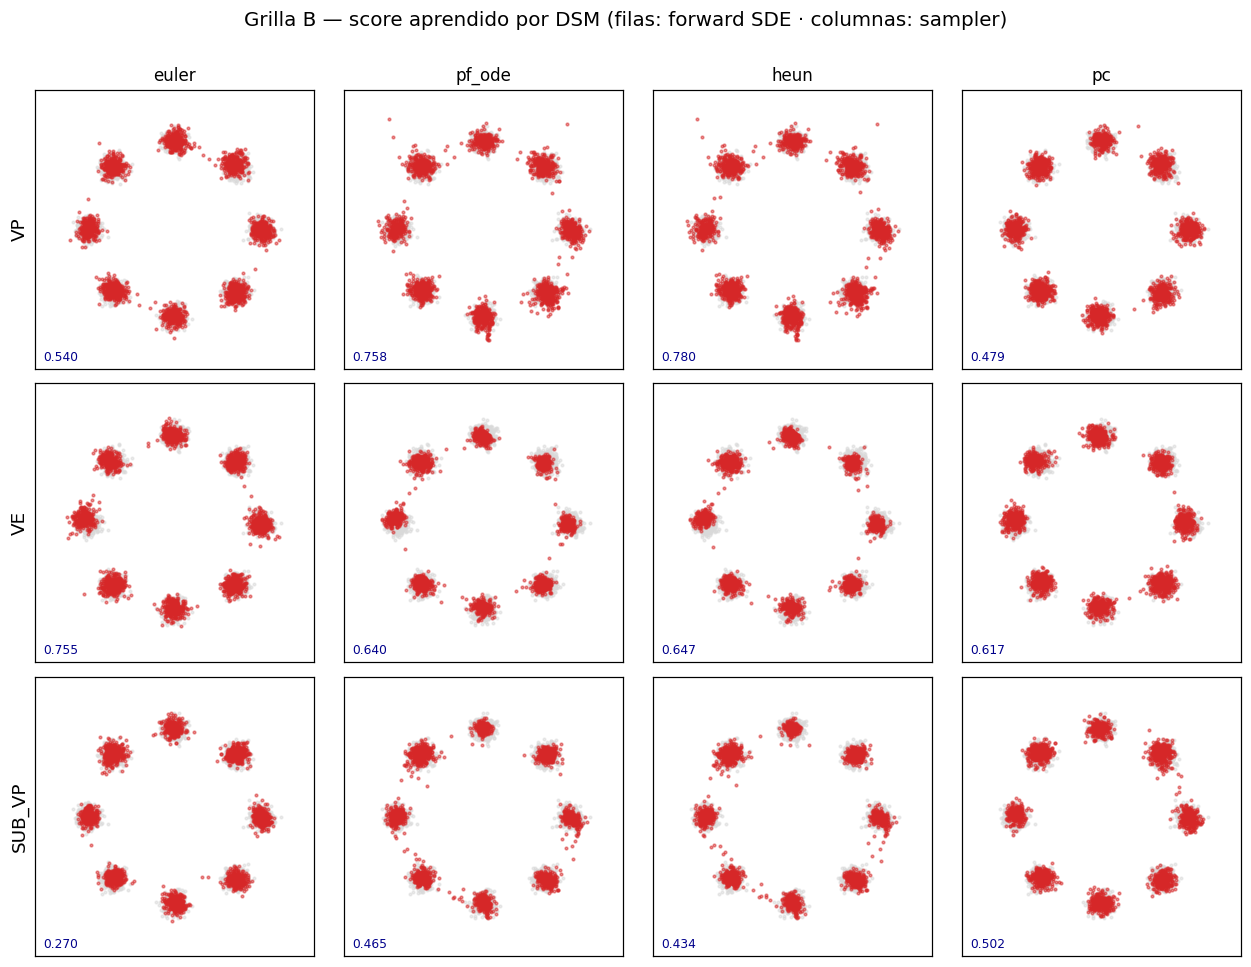

  1.1s


In [ ]:
print("Grilla B: score APRENDIDO (el error de la red entra en juego)")
t0 = time.time()
grilla_red = corre_grilla(
    lambda nombre, sde: redes[nombre],
    "Grilla B — score aprendido por DSM (filas: forward SDE · columnas: sampler)",
)

## 7. La descomposición del error

Las dos grillas lado a lado, como números. Con score exacto lo que queda es **discretización + truncación**; con score
aprendido se suma el **error de estimación del score**. La diferencia entre columnas es, celda por celda, lo que aporta la red.

celda                    A: exacto  B: aprendido     B - A
------------------------------------------------------------
vp/euler                    0.1757        0.5399   +0.3642
vp/pf_ode                   0.1187        0.7577   +0.6390
vp/heun                     0.1315        0.7801   +0.6485
vp/pc                       0.1442        0.4795   +0.3353
ve/euler                    0.1509        0.7555   +0.6046
ve/pf_ode                   0.3796        0.6401   +0.2605
ve/heun                     0.3700        0.6474   +0.2774
ve/pc                       0.2022        0.6166   +0.4144
sub_vp/euler                0.1424        0.2703   +0.1278
sub_vp/pf_ode               0.1115        0.4653   +0.3538
sub_vp/heun                 0.1314        0.4341   +0.3027
sub_vp/pc                   0.1333        0.5021   +0.3688


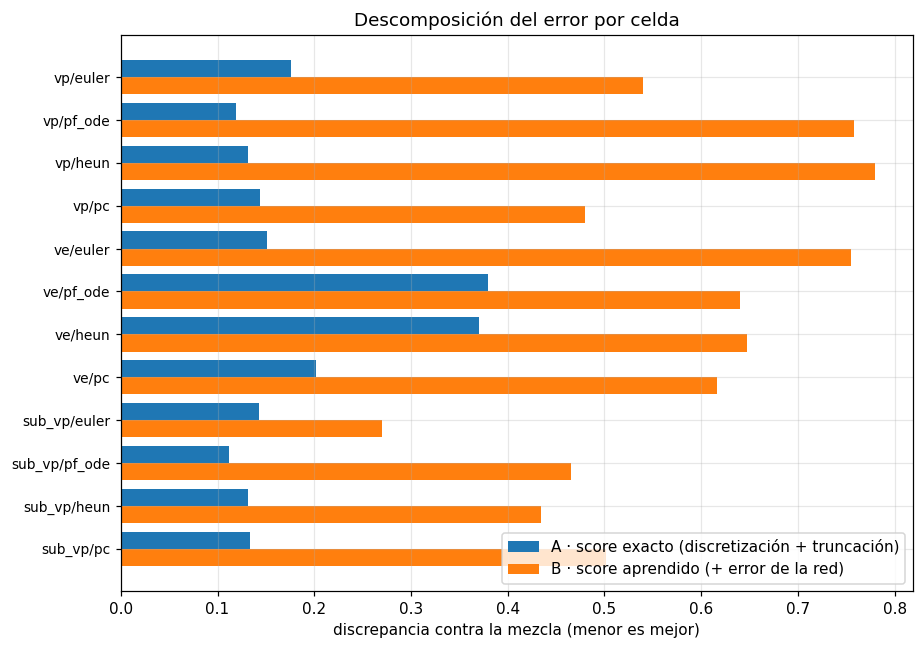

In [27]:
print(f"{'celda':22s} {'A: exacto':>11s} {'B: aprendido':>13s} {'B - A':>9s}")
print("-" * 60)
filas = []
for nom_sde in SDES:
    for nom_s in SAMPLERS:
        a = grilla_exacta[(nom_sde, nom_s)][1]
        b = grilla_red[(nom_sde, nom_s)][1]
        filas.append((f"{nom_sde}/{nom_s}", a, b))
        print(f"{nom_sde+'/'+nom_s:22s} {a:11.4f} {b:13.4f} {b-a:+9.4f}")

etiquetas = [f[0] for f in filas]
va = np.array([f[1] for f in filas]); vb = np.array([f[2] for f in filas])
y = np.arange(len(filas))
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.barh(y - 0.2, va, height=0.4, label="A · score exacto (discretización + truncación)")
ax.barh(y + 0.2, vb, height=0.4, label="B · score aprendido (+ error de la red)")
ax.set_yticks(y); ax.set_yticklabels(etiquetas, fontsize=9); ax.invert_yaxis()
ax.set_xlabel("discrepancia contra la mezcla (menor es mejor)")
ax.set_title("Descomposición del error por celda"); ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## 8. Truncación: qué queda del último paso

El reverso se integra de $T$ hasta $t_\epsilon > 0$, no hasta cero. Esa truncación deja un **suavizado residual**: lo generado
es $p_{t_\epsilon}$, no $p_0$. Con score exacto se puede aislar el efecto, porque no hay error de red que lo tape.

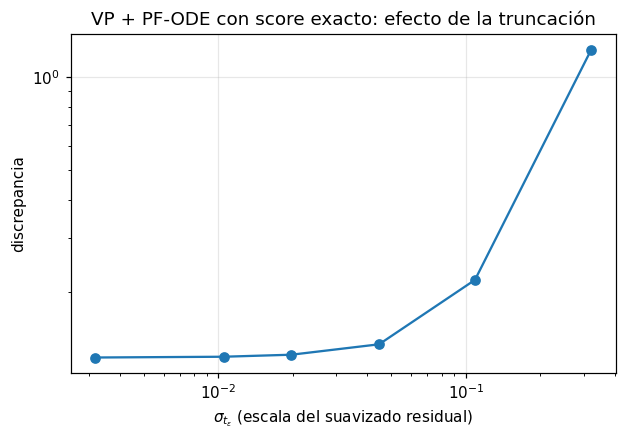

  t_eps=  1e-01  sigma= 0.32205  discrepancia=1.2320
  t_eps=  3e-02  sigma= 0.10901  discrepancia=0.2195
  t_eps=  1e-02  sigma= 0.04464  discrepancia=0.1355
  t_eps=  3e-03  sigma= 0.01974  discrepancia=0.1253
  t_eps=  1e-03  sigma= 0.01049  discrepancia=0.1234
  t_eps=  1e-04  sigma= 0.00318  discrepancia=0.1227


In [28]:
eps_vals = [1e-1, 3e-2, 1e-2, 3e-3, 1e-3, 1e-4]
sde = make_sde("vp")
ora = MixtureOracle(mixtura, sde)
discs, sigmas = [], []
for eps in eps_vals:
    smp = make_sampler("pf_ode", sde, ora, n_steps=300, t_eps=eps)
    g = gen_device()
    xs = smp.sample(2500, generator=g, device=DEVICE).cpu().numpy()
    discs.append(discrepancia(xs, mixtura))
    _, sig = ora.marginal_params(torch.tensor([eps]))
    sigmas.append(float(sig))

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.plot(sigmas, discs, marker="o")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$\sigma_{t_\epsilon}$ (escala del suavizado residual)")
ax.set_ylabel("discrepancia")
ax.set_title("VP + PF-ODE con score exacto: efecto de la truncación")
plt.show()

for eps, sig, d in zip(eps_vals, sigmas, discs):
    print(f"  t_eps={eps:7.0e}  sigma={sig:8.5f}  discrepancia={d:.4f}")

## Cierre

- La **matriz 3 × 4** corrió dos veces sobre la misma mezcla, con el mismo $x_T$ en las 12 celdas, y la red fija como variable
  de control.
- Con **score exacto** toda diferencia entre celdas es del sampler: es el Eje 2 aislado, que es imposible de ver cuando el
  error de la red está mezclado.
- La **diferencia entre las dos grillas** es lo que aporta el error de estimación del score, celda por celda.
- El **sesgo de inicialización** quedó cuantificado por SDE, con cota cerrada y valor por cuadratura, en vez de argumentado.
- La **truncación** se midió contra la escala del suavizado residual que deja.

Lo que sigue en el laboratorio: métricas exactas ($W_2$ por transporte óptimo, KSD, recuperación de parámetros, verosimilitud
por PF-ODE) y el barrido del parámetro de estocasticidad $\lambda$ que interpola entre PF-ODE y la SDE reversa.